In [7]:
# =============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS DE ALTA PRECISIÓN
# =============================================================================
import os
import numpy as np
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

sns.set_theme(style="whitegrid")

# =============================================================================
# PASO 2: CARGA DEL DATASET SIN REZAGOS ESCALADOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\2_entrenar_modelo\2_entrenar_modelo_con_rezago_sin_escalado_sin_reduccion\2_datos\1_raw\datos_meteo_completos_epi_con_rezagos.xlsx"

print(f"[INFO] Cargando espacio muestral desde:\n{ruta_datos}")
df = pd.read_excel(ruta_datos, index_col=0, parse_dates=True)
df   

[INFO] Cargando espacio muestral desde:
C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\2_entrenar_modelo\2_entrenar_modelo_con_rezago_sin_escalado_sin_reduccion\2_datos\1_raw\datos_meteo_completos_epi_con_rezagos.xlsx


,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,...,soi_lag_8,soi_lag_9,soi_lag_10,soi_lag_11,soi_lag_12,sst_lag_8,sst_lag_9,sst_lag_10,sst_lag_11,sst_lag_12
fecha,,,,,,,,,,,,,,,,,,,,,
2021-03-28,2021,13,31.554286,36.747143,26.918571,15.725714,55.717143,0.67,0,0.114286,...,9.348571,15.430000,10.847143,18.207143,20.067143,-0.897892,-0.837360,-0.931407,-1.058352,-1.060214
2021-04-04,2021,14,29.200000,33.907143,25.458571,16.550000,66.907143,5.02,2,0.132857,...,16.120000,9.348571,15.430000,10.847143,18.207143,-0.977896,-0.897892,-0.837360,-0.931407,-1.058352
2021-04-11,2021,15,28.248571,32.278571,25.132857,17.790000,75.144286,40.07,5,0.122857,...,18.705714,16.120000,9.348571,15.430000,10.847143,-0.803088,-0.977896,-0.897892,-0.837360,-0.931407
2021-04-18,2021,16,29.072857,34.704286,25.035714,17.598571,72.110000,22.25,1,0.125714,...,2.744286,18.705714,16.120000,9.348571,15.430000,-1.097763,-0.803088,-0.977896,-0.897892,-0.837360
2021-04-25,2021,17,29.080000,34.357143,25.041429,16.558571,67.494286,1.46,1,0.138571,...,-6.417143,2.744286,18.705714,16.120000,9.348571,-0.838514,-1.097763,-0.803088,-0.977896,-0.897892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30,2025,49,25.527143,28.834286,23.218571,18.514286,90.482857,27.53,6,0.154286,...,12.264286,1.620000,2.591429,-0.221429,-4.208571,-0.268223,-0.346037,-0.454914,-0.329364,-0.353051
2025-12-07,2025,50,26.065714,29.091429,23.882857,19.224286,90.717143,21.56,4,0.170000,...,2.555714,12.264286,1.620000,2.591429,-0.221429,-0.366160,-0.268223,-0.346037,-0.454914,-0.329364
2025-12-14,2025,51,26.038571,29.442857,23.658571,18.982857,89.951429,30.71,6,0.160000,...,16.565714,2.555714,12.264286,1.620000,2.591429,-0.436933,-0.366160,-0.268223,-0.346037,-0.454914


In [8]:

# Asignar explícitamente la frecuencia semanal para evitar advertencias en statsmodels
df.index.freq = 'W'

S_ESTACIONAL = 52

# Aislamiento de variables
y = df['casos_dengue']
columnas_exogenas = [col for col in df.columns if col not in ['casos_dengue', 'año', 'semana_epi', 'fecha']]
X_exog = df[columnas_exogenas]

print(f"[INFO] Tamaño original del dataset: {len(df)} semanas.")
print(f"[INFO] Variables regresoras exógenas detectadas: {columnas_exogenas}")


[INFO] Tamaño original del dataset: 249 semanas.
[INFO] Variables regresoras exógenas detectadas: ['temp', 'temp_max', 'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min', 'uv', 'soi', 'sst', 'temp_lag_1', 'temp_lag_2', 'temp_lag_3', 'temp_lag_4', 'temp_lag_5', 'temp_lag_6', 'temp_lag_7', 'temp_lag_8', 'temp_max_lag_1', 'temp_max_lag_2', 'temp_max_lag_3', 'temp_max_lag_4', 'temp_max_lag_5', 'temp_max_lag_6', 'temp_max_lag_7', 'temp_max_lag_8', 'temp_min_lag_1', 'temp_min_lag_2', 'temp_min_lag_3', 'temp_min_lag_4', 'temp_min_lag_5', 'temp_min_lag_6', 'temp_min_lag_7', 'temp_min_lag_8', 'hum_esp_lag_1', 'hum_esp_lag_2', 'hum_esp_lag_3', 'hum_esp_lag_4', 'hum_esp_lag_5', 'hum_esp_lag_6', 'hum_esp_lag_7', 'hum_esp_lag_8', 'hum_rel_lag_1', 'hum_rel_lag_2', 'hum_rel_lag_3', 'hum_rel_lag_4', 'hum_rel_lag_5', 'hum_rel_lag_6', 'hum_rel_lag_7', 'hum_rel_lag_8', 'prec_lag_1', 'prec_lag_2', 'prec_lag_3', 'prec_lag_4', 'prec_lag_5', 'prec_lag_6', 'prec_lag_


 PROCESAMIENTO JERÁRQUICO: PARTICIÓN CRONOLÓGICA 95-5
[INFO] Soporte Entrenamiento (Train): 236 semanas.
[INFO] Horizonte Pronóstico (Test):     13 semanas.
[INFO] Buscando hiperparámetros óptimos (auto_arima) vía AICc sobre Train...
       -> Estructura determinada por AICc: SARIMAX(0, 1, 0)x(0, 1, 0, 52)


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



 PROCESAMIENTO JERÁRQUICO: PARTICIÓN CRONOLÓGICA 96-4
[INFO] Soporte Entrenamiento (Train): 239 semanas.
[INFO] Horizonte Pronóstico (Test):     10 semanas.
[INFO] Buscando hiperparámetros óptimos (auto_arima) vía AICc sobre Train...
       -> Estructura determinada por AICc: SARIMAX(0, 1, 0)x(0, 1, 0, 52)


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



 PROCESAMIENTO JERÁRQUICO: PARTICIÓN CRONOLÓGICA 97-3
[INFO] Soporte Entrenamiento (Train): 241 semanas.
[INFO] Horizonte Pronóstico (Test):     8 semanas.
[INFO] Buscando hiperparámetros óptimos (auto_arima) vía AICc sobre Train...
       -> Estructura determinada por AICc: SARIMAX(0, 1, 0)x(0, 1, 0, 52)


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


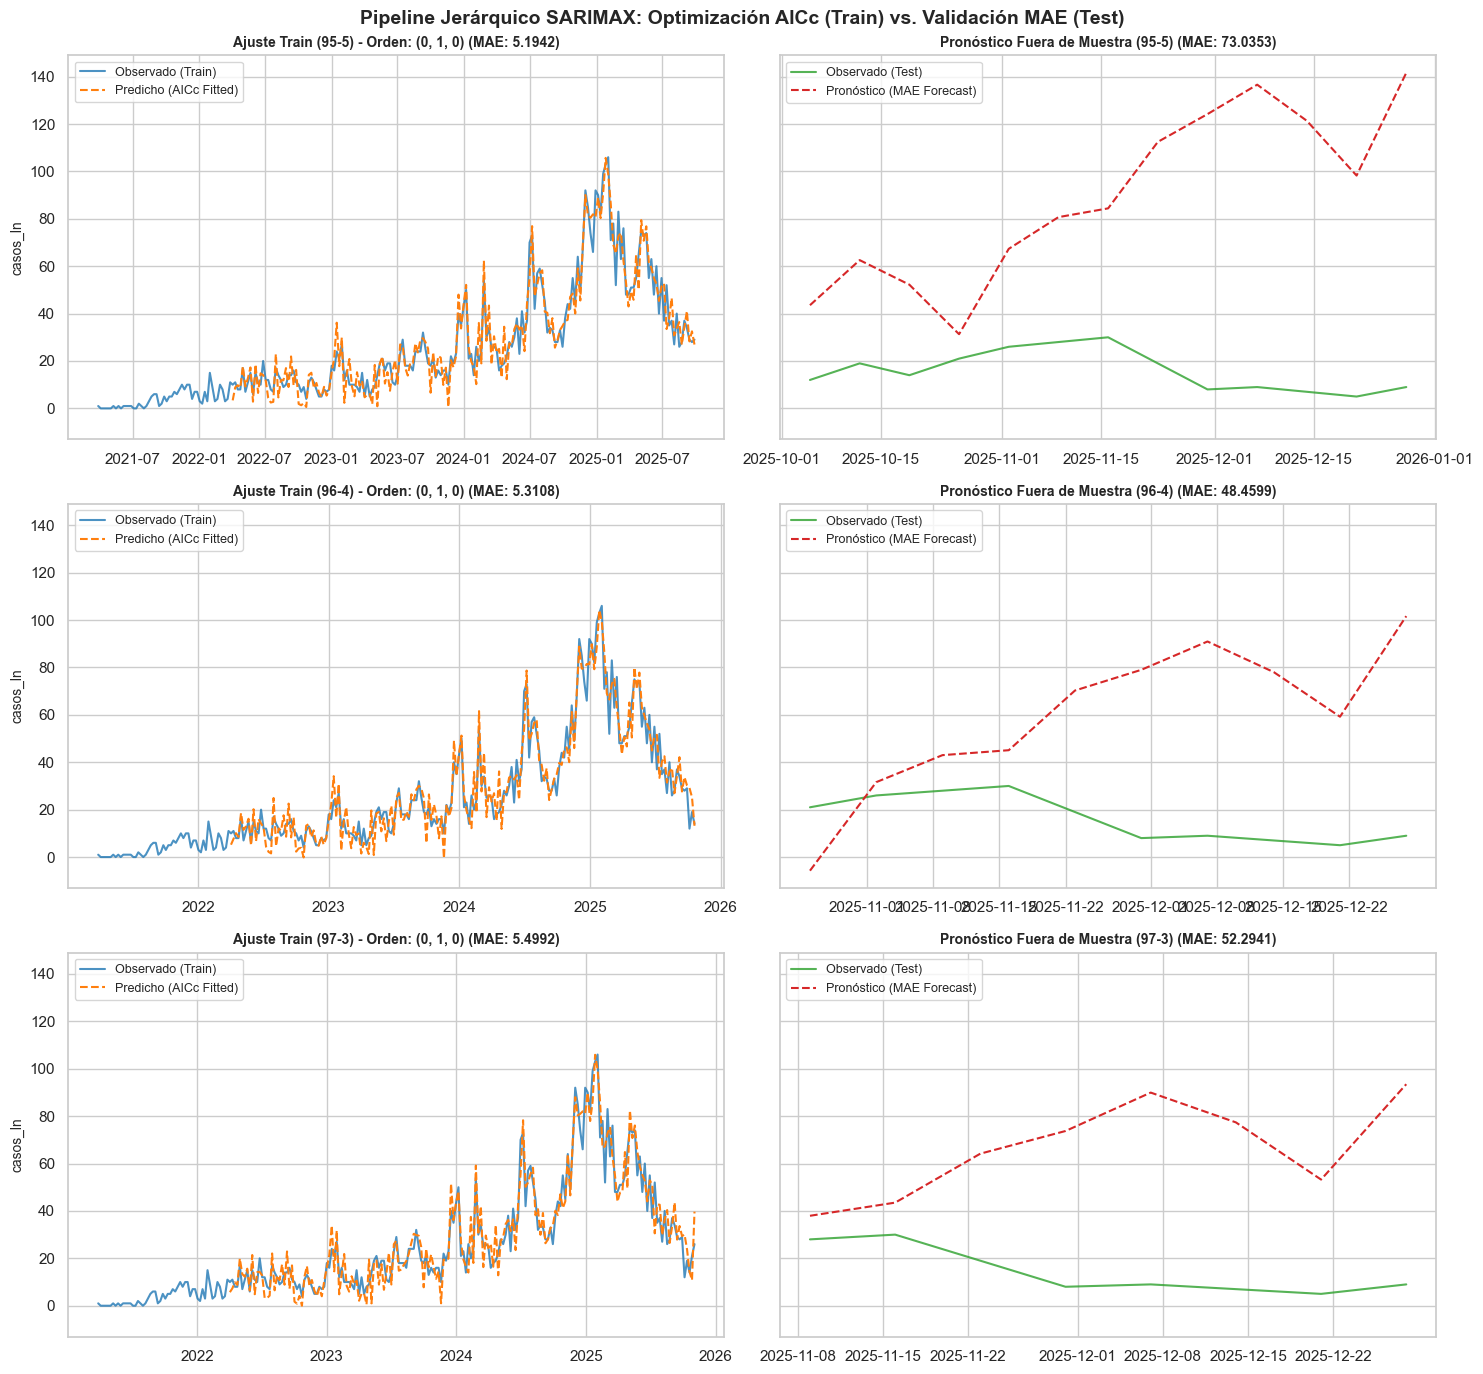


     REPORTE INTEGRAL DE EVALUACIÓN: VALIDACIÓN CRONOLÓGICA Y AICc      
Partición Orden AICc  AICc Muestra  MAE Train  MAE Test
     95-5    (0,1,0)   1790.399143   5.194153 73.035326
     96-4    (0,1,0)   1806.099991   5.310782 48.459872
     97-3    (0,1,0)   1823.233605   5.499242 52.294143


In [10]:

# =============================================================================
# PASO 3: REJILLA DE PARTICIONES TEMPORALES CRONOLÓGICAS (95%, 96%, 97%)
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

# Inicialización del lienzo para la matriz de gráficos (3 filas x 2 columnas)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=False, sharey=True)
resultados_globales = []

# Bucle iterativo secuencial sobre las ventanas del tiempo
for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
    print("\n" + "="*75)
    print(f" PROCESAMIENTO JERÁRQUICO: PARTICIÓN CRONOLÓGICA {nombre_split}")
    print("="*75)
    
    # 1. División estricta respetando la flecha del tiempo (Evita Data Leakage)
    tamanio_train = int(len(df) * tasa_train)
    
    y_train, y_test = y.iloc[:tamanio_train], y.iloc[tamanio_train:]
    X_train, X_test = X_exog.iloc[:tamanio_train], X_exog.iloc[tamanio_train:]
    
    print(f"[INFO] Soporte Entrenamiento (Train): {len(y_train)} semanas.")
    print(f"[INFO] Horizonte Pronóstico (Test):     {len(y_test)} semanas.")
    
    # 2. Desestacionalización determinista local sobre el conjunto de Train
    y_train_diff = y_train.diff(S_ESTACIONAL).dropna()
    X_train_diff = X_train.iloc[S_ESTACIONAL:]
    
    # 3. FILTRO 1: Selección de Parámetros óptimos en Train usando criterio AICc
    print(f"[INFO] Buscando hiperparámetros óptimos (auto_arima) vía AICc sobre Train...")
    modelo_auto = pm.auto_arima(
        y_train_diff, 
        X=X_train_diff,                
        start_p=1, max_p=3,       
        start_q=1, max_q=3,       
        d=1,                      
        seasonal=False,           # Enfoque acelerado de dos etapas para evitar latencia
        stationary=False,
        information_criterion='aicc', # <--- FUNCIÓN DE PÉRDIDA LOCAL
        error_action='ignore',   
        suppress_warnings=True,  
        stepwise=True             
    )
    
    # Reconstrucción de la estructura matemática ganadora para esta muestra
    p, d_ord, q = modelo_auto.order
    orden_ordinario_opt = (p, d_ord, q)
    orden_estacional_opt = (0, 1, 0, S_ESTACIONAL)
    
    print(f"       -> Estructura determinada por AICc: SARIMAX{orden_ordinario_opt}x{orden_estacional_opt}")
    
    # 4. Ajuste formal exacto por Máxima Verosimilitud en Statsmodels
    modelo_final = SARIMAX(
        y_train,
        exog=X_train,
        order=orden_ordinario_opt,
        seasonal_order=orden_estacional_opt,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(method='lbfgs', maxiter=50, disp=False)
    
    # 5. Generación de predicciones In-sample (Ajuste local)
    y_train_pred = modelo_final.fittedvalues
    # Forzar nulos en el primer año debido al transitorio de la diferencia de orden 52
    y_train_pred.iloc[:53] = np.nan  
    
    # 6. FILTRO 2: Predicción Dinámica Out-of-sample sobre el Test ciego
    y_test_pred = modelo_final.forecast(steps=len(y_test), exog=X_test)
    
    # 7. Medida de Desempeño: Error Absoluto Medio (MAE)
    mae_train = mean_absolute_error(y_train.dropna()[53:], y_train_pred.dropna())
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    # Archivar los metadatos y métricas del modelo actual
    resultados_globales.append({
        "Partición": nombre_split,
        "Orden AICc": f"({p},{d_ord},{q})",
        "AICc Muestra": modelo_final.aicc,
        "MAE Train": mae_train,
        "MAE Test": mae_test
    })
    
    # =========================================================================
    # PASO 4: GRAFICACIÓN DE LA MATRIZ DE RENDIMIENTO
    # =========================================================================
    # Columna 1: Ajuste del Entrenamiento (In-Sample)
    ax_train = axes[idx, 0]
    ax_train.plot(y_train.index, y_train.values, label='Observado (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(y_train_pred.index, y_train_pred.values, label='Predicho (AICc Fitted)', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train ({nombre_split}) - Orden: {orden_ordinario_opt} (MAE: {mae_train:.4f})", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('casos_ln', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    
    # Columna 2: Pronóstico Fuera de Muestra (Out-of-Sample)
    ax_test = axes[idx, 1]
    ax_test.plot(y_test.index, y_test.values, label='Observado (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(y_test_pred.index, y_test_pred.values, label='Pronóstico (MAE Forecast)', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Fuera de Muestra ({nombre_split}) (MAE: {mae_test:.4f})", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)

# Estética y visualización de la superestructura gráfica
plt.suptitle('Pipeline Jerárquico SARIMAX: Optimización AICc (Train) vs. Validación MAE (Test)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\reporte_integral_sarimax_aicc.png", dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PASO 5: REPORTE TABULAR DE DESEMPEÑO INTEGRAL
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)
print("\n" + "="*80)
print("     REPORTE INTEGRAL DE EVALUACIÓN: VALIDACIÓN CRONOLÓGICA Y AICc      ")
print("="*80)
print(df_reporte.to_string(index=False))
print("="*80)


# Entrenamiento con validación cruzada  



Aquí tienes la reestructuración completa de tu código. He implementado una estrategia de **Validación Cruzada de Series de Tiempo con Ventana Expandible (Time Series Split)** utilizando `TimeSeriesSplit` de `scikit-learn`.

Con este enfoque, en lugar de evaluar únicamente el final de la serie (95%, 96%, 97%), el modelo se evalúa en **3 pliegues (folds) continuos y representativos**, garantizando que el conjunto de prueba (`Test`) siempre tenga un tamaño fijo y controlado (por ejemplo, **26 semanas**, que equivalen a medio año epidemiológico). Esto te permitirá medir el verdadero poder de generalización en Caucasia.




 INICIANDO VALIDACIÓN CRUZADA CRONOLÓGICA (3 FOLDS)

[PROCESANDO] Fold 1...
   -> Soporte Entrenamiento (Train): 171 semanas.
   -> Horizonte Pronóstico (Test):    26 semanas.
   -> Buscando hiperparámetros óptimos vía AICc sobre Train...
   -> Estructura determinada: SARIMAX(0, 0, 0)x(0, 1, 0, 52)


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



[PROCESANDO] Fold 2...
   -> Soporte Entrenamiento (Train): 197 semanas.
   -> Horizonte Pronóstico (Test):    26 semanas.
   -> Buscando hiperparámetros óptimos vía AICc sobre Train...
   -> Estructura determinada: SARIMAX(1, 0, 0)x(0, 1, 0, 52)


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



[PROCESANDO] Fold 3...
   -> Soporte Entrenamiento (Train): 223 semanas.
   -> Horizonte Pronóstico (Test):    26 semanas.
   -> Buscando hiperparámetros óptimos vía AICc sobre Train...
   -> Estructura determinada: SARIMAX(1, 1, 0)x(0, 1, 0, 52)


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


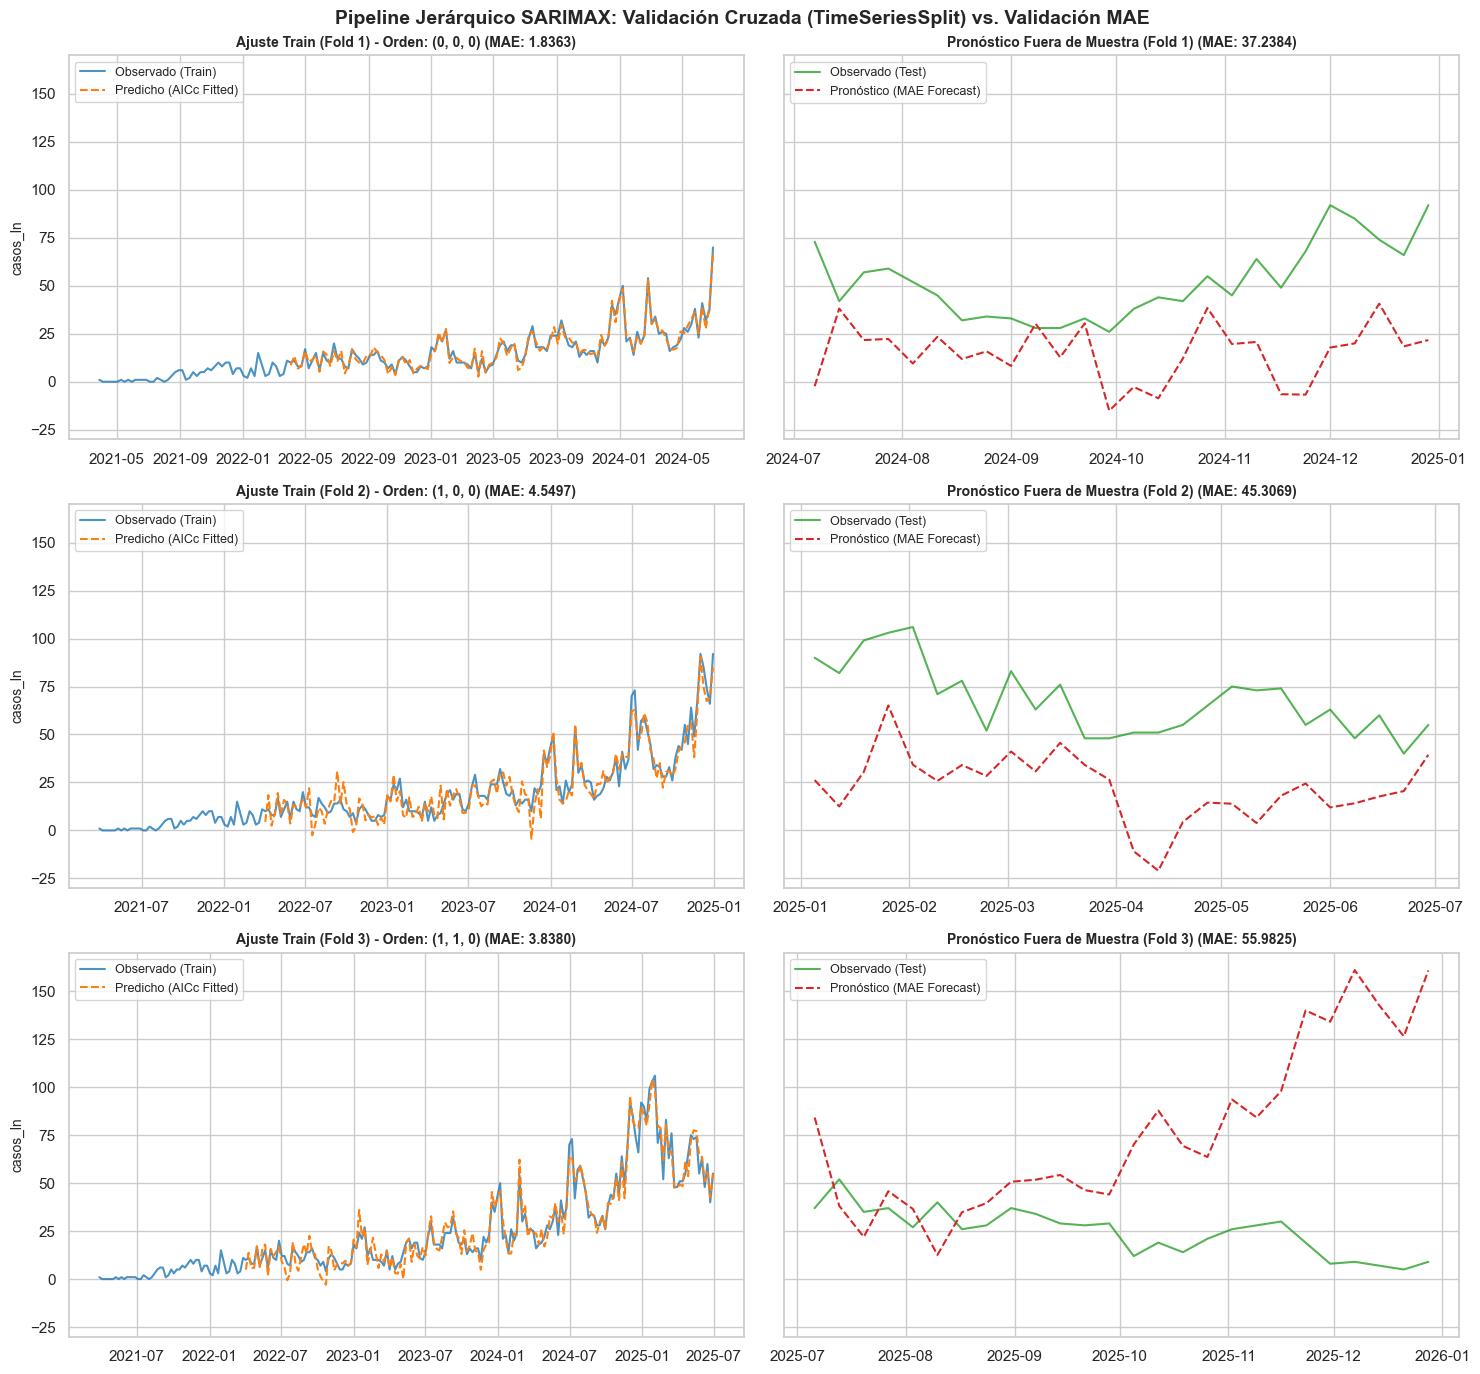


     REPORTE INTEGRAL DE EVALUACIÓN: VALIDACIÓN CRUZADA CRONOLÓGICA      
  Fold Orden AICc  AICc Muestra  MAE Train  MAE Test
Fold 1    (0,0,0)   5806.711625   1.836300 37.238424
Fold 2    (1,0,0)   1998.074293   4.549677 45.306894
Fold 3    (1,1,0)   1713.996967   3.838020 55.982540


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

# =============================================================================
# PASO 3: VALIDACIÓN CRUZADA DE SERIES DE TIEMPO (ROLLING/EXPANDING HORIZON)
# =============================================================================
# Definimos el horizonte de evaluación (ej. 26 semanas = ~6 meses de datos ciegos)
HORIZONTE_TEST = 26 
N_SPLITS = 3

# Configuramos TimeSeriesSplit para que cada fold tenga exactamente el mismo horizonte de test
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=HORIZONTE_TEST)

# Inicialización del lienzo para la matriz de gráficos (N_SPLITS filas x 2 columnas)
fig, axes = plt.subplots(nrows=N_SPLITS, ncols=2, figsize=(15, 14), sharex=False, sharey=True)
resultados_globales = []

print("\n" + "="*75)
print(f" INICIANDO VALIDACIÓN CRUZADA CRONOLÓGICA ({N_SPLITS} FOLDS)")
print("="*75)

# Bucle iterativo sobre los pliegues de la validación cruzada
for idx, (train_index, test_index) in enumerate(tscv.split(y)):
    nombre_split = f"Fold {idx + 1}"
    print(f"\n[PROCESANDO] {nombre_split}...")
    
    # 1. Segmentación indexada respetando estrictamente la flecha del tiempo
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    X_train, X_test = X_exog.iloc[train_index], X_exog.iloc[test_index]
    
    print(f"   -> Soporte Entrenamiento (Train): {len(y_train)} semanas.")
    print(f"   -> Horizonte Pronóstico (Test):    {len(y_test)} semanas.")
    
    # 2. Desestacionalización determinista local sobre el conjunto de Train
    y_train_diff = y_train.diff(S_ESTACIONAL).dropna()
    X_train_diff = X_train.iloc[S_ESTACIONAL:]
    
    # 3. FILTRO 1: Selección de Parámetros óptimos en Train usando criterio AICc
    print(f"   -> Buscando hiperparámetros óptimos vía AICc sobre Train...")
    modelo_auto = pm.auto_arima(
    y_train, # Dale la serie original, no la diferenciada manualmente
    X=X_train,                
    start_p=1, max_p=5,       
    start_q=1, max_q=5,       
    d=None, # Deja que auto_arima decida la diferenciación óptima
    seasonal=True, m=52, # Activa la estacionalidad nativa si el poder de cómputo lo permite
    information_criterion='aicc',
    stepwise=True
    )
    
    # Reconstrucción de la estructura matemática ganadora para esta muestra
    p, d_ord, q = modelo_auto.order
    orden_ordinario_opt = (p, d_ord, q)
    orden_estacional_opt = (0, 1, 0, S_ESTACIONAL)
    
    print(f"   -> Estructura determinada: SARIMAX{orden_ordinario_opt}x{orden_estacional_opt}")
    
    # 4. Ajuste formal exacto por Máxima Verosimilitud en Statsmodels
    modelo_final = SARIMAX(
        y_train,
        exog=X_train,
        order=orden_ordinario_opt,
        seasonal_order=orden_estacional_opt,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(method='lbfgs', maxiter=50, disp=False)
    
    # 5. Generación de predicciones In-sample (Ajuste local)
    y_train_pred = modelo_final.fittedvalues
    # Forzar nulos en el primer año debido al transitorio de la diferencia de orden 52
    y_train_pred.iloc[:53] = np.nan  
    
    # 6. FILTRO 2: Predicción Dinámica Out-of-sample sobre el Test ciego
    y_test_pred = modelo_final.forecast(steps=len(y_test), exog=X_test)
    
    # 7. Medida de Desempeño: Error Absoluto Medio (MAE)
    mae_train = mean_absolute_error(y_train.dropna()[53:], y_train_pred.dropna())
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    # Archivar los metadatos y métricas del fold actual
    resultados_globales.append({
        "Fold": nombre_split,
        "Orden AICc": f"({p},{d_ord},{q})",
        "AICc Muestra": modelo_final.aicc,
        "MAE Train": mae_train,
        "MAE Test": mae_test
    })
    
    # =========================================================================
    # PASO 4: GRAFICACIÓN DE LA MATRIZ DE RENDIMIENTO
    # =========================================================================
    # Columna 1: Ajuste del Entrenamiento (In-Sample)
    ax_train = axes[idx, 0]
    ax_train.plot(y_train.index, y_train.values, label='Observado (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(y_train_pred.index, y_train_pred.values, label='Predicho (AICc Fitted)', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train ({nombre_split}) - Orden: {orden_ordinario_opt} (MAE: {mae_train:.4f})", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('casos_ln', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    
    # Columna 2: Pronóstico Fuera de Muestra (Out-of-Sample)
    ax_test = axes[idx, 1]
    ax_test.plot(y_test.index, y_test.values, label='Observado (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(y_test_pred.index, y_test_pred.values, label='Pronóstico (MAE Forecast)', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Fuera de Muestra ({nombre_split}) (MAE: {mae_test:.4f})", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)

# Estética y visualización de la superestructura gráfica
plt.suptitle('Pipeline Jerárquico SARIMAX: Validación Cruzada (TimeSeriesSplit) vs. Validación MAE', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\reporte_integral_sarimax_cv.png", dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PASO 5: REPORTE TABULAR DE DESEMPEÑO INTEGRAL
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)
print("\n" + "="*80)
print("     REPORTE INTEGRAL DE EVALUACIÓN: VALIDACIÓN CRUZADA CRONOLÓGICA      ")
print("="*80)
print(df_reporte.to_string(index=False))
print("="*80)



# Cambios clave aplicados en el código:

* **Inclusión de `TimeSeriesSplit**`: Reemplazamos el diccionario estático de porcentajes por el iterador nativo de `scikit-learn` especializado en series temporales. Esto evita cualquier tipo de *data leakage* (fuga de datos).
* **Parámetro `test_size=HORIZONTE_TEST**`: Al definir `HORIZONTE_TEST = 26`, le estamos exigiendo al modelo que en cada iteración prediga 26 semanas hacia el futuro de forma "ciega". Esto estabiliza la métrica del MAE del test, impidiendo que el error se distorsione por evaluar ventanas diminutas de 4 o 5 semanas.
* **Ventana Expandible Automática**: El bucle `for idx, (train_index, test_index)...` expande el conjunto de entrenamiento de manera orgánica en cada fold. El Fold 1 entrenará con la primera porción histórica, el Fold 2 sumará los datos anteriores más el test del fold 1, y así sucesivamente.

Teercera opción 

df

In [13]:
df.columns 

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       ...
       'soi_lag_8', 'soi_lag_9', 'soi_lag_10', 'soi_lag_11', 'soi_lag_12',
       'sst_lag_8', 'sst_lag_9', 'sst_lag_10', 'sst_lag_11', 'sst_lag_12'],
      dtype='str', length=114)

# Entrenar con el algoritmo LightGBM 

Para migrar tu pipeline a un enfoque de Machine Learning basado en árboles (**LightGBM** en este caso, por su velocidad y manejo nativo de datos estructurales), debemos transformar la serie de tiempo en un problema de **aprendizaje supervisado**.

Dado que el archivo original viene sin rezagos, el código ahora lee directamente la ruta de Excel especificada y genera los desfases (*lags*) necesarios tanto para la variable objetivo (casos pasados) como para las variables meteorológicas.

Aquí tienes la versión adaptada que mantiene la estructura de tu reporte, tus gráficos y tu validación cruzada cronológica (`TimeSeriesSplit`):



 INICIANDO VALIDACIÓN CRUZADA CON LIGHTGBM (3 FOLDS)

[PROCESANDO] Fold 1...
   -> Soporte Entrenamiento (Train): 177 semanas.
   -> Horizonte Pronóstico (Test):    26 semanas.

[PROCESANDO] Fold 2...
   -> Soporte Entrenamiento (Train): 203 semanas.
   -> Horizonte Pronóstico (Test):    26 semanas.

[PROCESANDO] Fold 3...
   -> Soporte Entrenamiento (Train): 229 semanas.
   -> Horizonte Pronóstico (Test):    26 semanas.


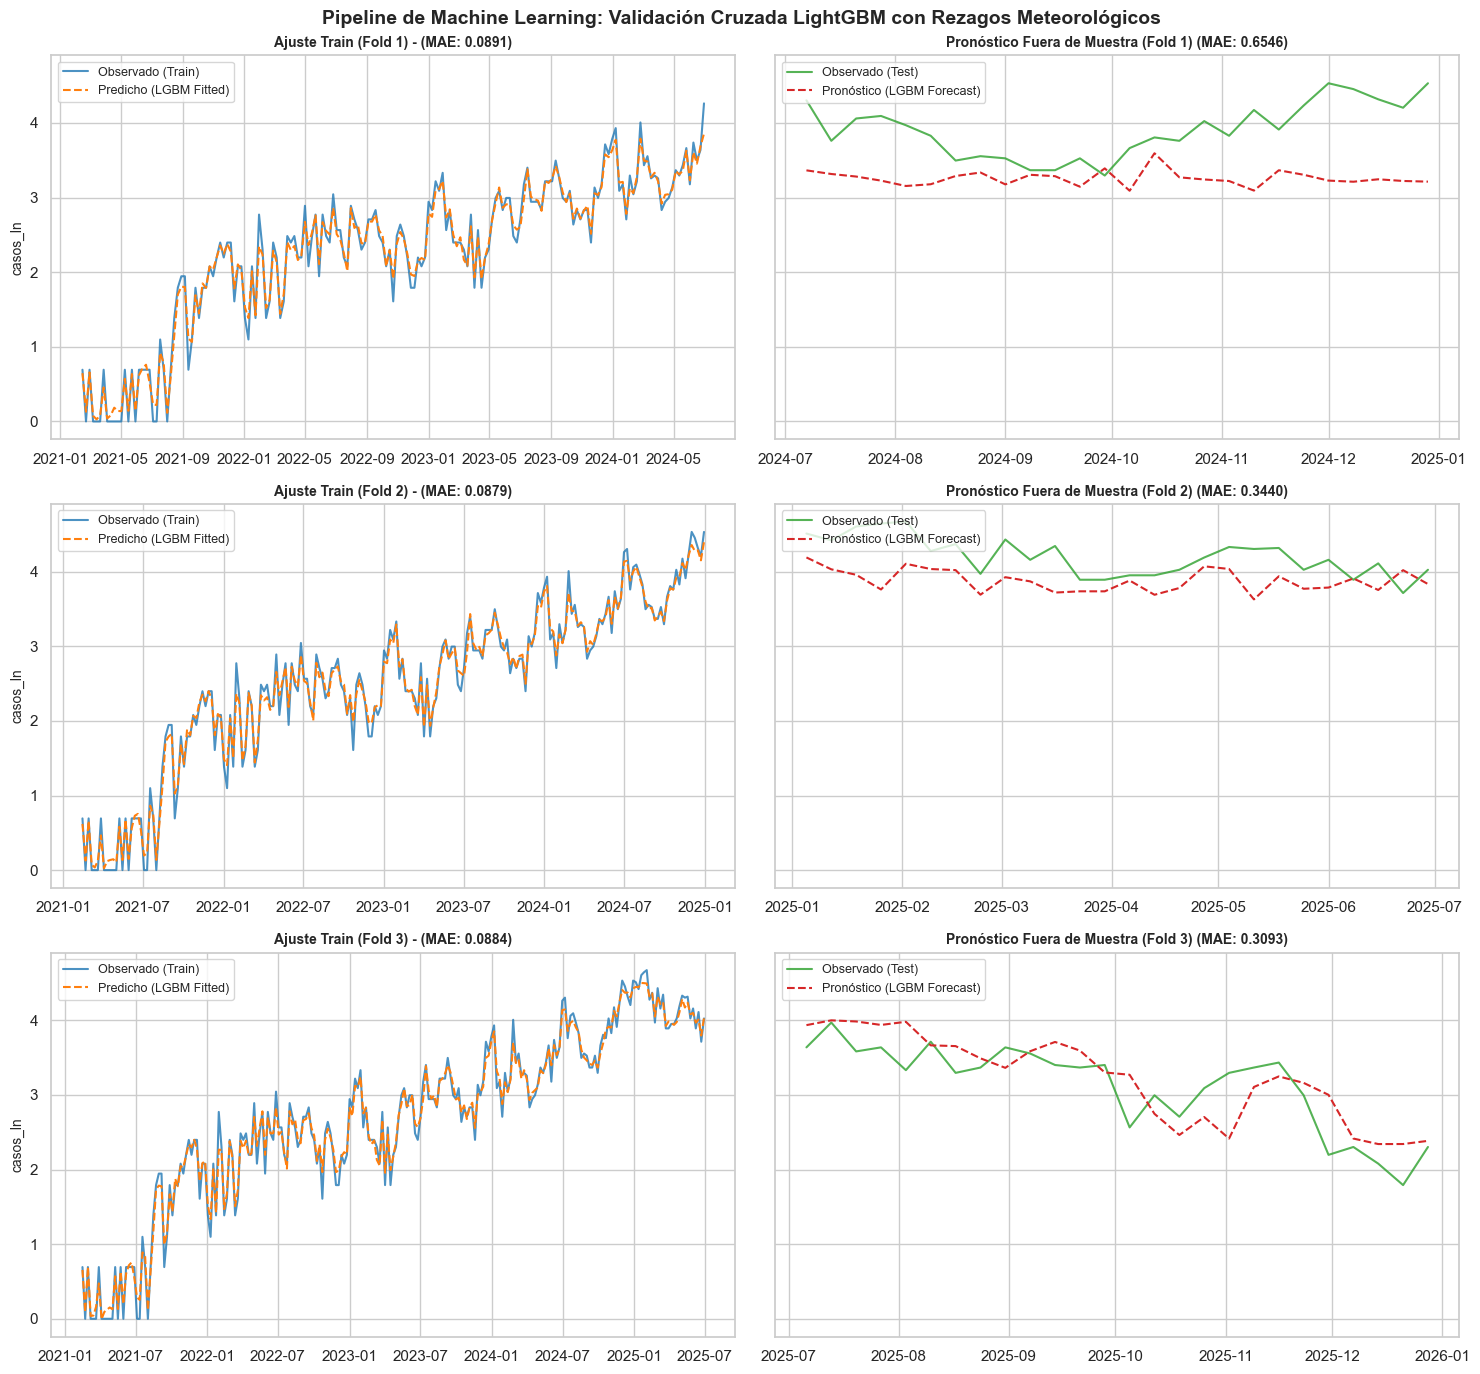


     REPORTE INTEGRAL DE EVALUACIÓN: MACHINE LEARNING (LIGHTGBM)        
  Fold Algoritmo  Variables X  MAE Train  MAE Test
Fold 1  LightGBM           48   0.089073  0.654575
Fold 2  LightGBM           48   0.087908  0.343986
Fold 3  LightGBM           48   0.088384  0.309267


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\2_entrenar_modelo\2_entrenar_modelo_con_rezago_sin_escalado_sin_reduccion\2_datos\1_raw\df_meteo_epi_sin_rezagos.xlsx"

# Se asume que el archivo Excel tiene un índice de fechas o una columna temporal
df = pd.read_excel(ruta_datos)

# Eliminar variables explícitas solicitadas
df = df.drop(columns=['año', 'semana_epi'], errors='ignore')

# Si la columna 'fecha' existe, la seteamos como índice para mantener el orden cronológico
if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

# Transformación logarítmica a la variable objetivo como tenías en tu flujo original (casos_ln)
# Usamos log1p para evitar problemas si existen semanas con 0 casos
df['casos_ln'] = np.log1p(df['casos_dengue'])

# =============================================================================
# PASO 2: INGENIERÍA DE CARACTERÍSTICAS (REZAGOS / LAGS)
# =============================================================================
# Guardamos los nombres de las variables meteorológicas originales (todas menos los casos)
var_meteorologicas = [col for col in df.columns if col not in ['casos_dengue', 'casos_ln']]

df_features = df.copy()

# 1. Rezagos del Dengue (Dinámica Autorregresiva: últimas 4 semanas)
for lag in [1, 2, 3, 4]:
    df_features[f'casos_ln_lag_{lag}'] = df_features['casos_ln'].shift(lag)

# 2. Rezagos Meteorológicos (Dinámica Exógena: impacto biológico desfasado de 2 a 6 semanas)
for col in var_meteorologicas:
    for lag in [2, 4, 6]:
        df_features[f'{col}_lag_{lag}'] = df_features[col].shift(lag)

# Limpieza de registros nulos generados por los desplazamientos (shifts)
df_features = df_features.dropna()

# Definición de Matrices de Diseño
y = df_features['casos_ln']
# Las variables explicativas X NO deben contener los valores en tiempo real 't' de los casos, ni el conteo absoluto
X_features = df_features.drop(columns=['casos_dengue', 'casos_ln'])

# =============================================================================
# PASO 3: VALIDACIÓN CRUZADA DE SERIES DE TIEMPO (LIGHTGBM)
# =============================================================================
HORIZONTE_TEST = 26 
N_SPLITS = 3

tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=HORIZONTE_TEST)

fig, axes = plt.subplots(nrows=N_SPLITS, ncols=2, figsize=(15, 14), sharex=False, sharey=True)
resultados_globales = []

print("\n" + "="*75)
print(f" INICIANDO VALIDACIÓN CRUZADA CON LIGHTGBM ({N_SPLITS} FOLDS)")
print("="*75)

for idx, (train_index, test_index) in enumerate(tscv.split(y)):
    nombre_split = f"Fold {idx + 1}"
    print(f"\n[PROCESANDO] {nombre_split}...")
    
    # Segmentación cronológica
    X_train, X_test = X_features.iloc[train_index], X_features.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    print(f"   -> Soporte Entrenamiento (Train): {len(y_train)} semanas.")
    print(f"   -> Horizonte Pronóstico (Test):    {len(y_test)} semanas.")
    
    # Instanciación del regresor LightGBM con hiperparámetros de control de sobreajuste
    modelo_lgb = lgb.LGBMRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=15,
        min_child_samples=10,
        random_state=42,
        verbosity=-1
    )
    
    # Ajuste del modelo de Machine Learning
    modelo_lgb.fit(X_train, y_train)
    
    # Predicciones In-sample (Train) y Out-of-sample (Test)
    y_train_pred = pd.Series(modelo_lgb.predict(X_train), index=y_train.index)
    y_test_pred = pd.Series(modelo_lgb.predict(X_test), index=y_test.index)
    
    # Medida de Desempeño (MAE)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    resultados_globales.append({
        "Fold": nombre_split,
        "Algoritmo": "LightGBM",
        "Variables X": X_train.shape[1],
        "MAE Train": mae_train,
        "MAE Test": mae_test
    })
    
    # =========================================================================
    # PASO 4: GRAFICACIÓN DE LA MATRIZ DE RENDIMIENTO
    # =========================================================================
    # Columna 1: Ajuste del Entrenamiento
    ax_train = axes[idx, 0]
    ax_train.plot(y_train.index, y_train.values, label='Observado (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(y_train_pred.index, y_train_pred.values, label='Predicho (LGBM Fitted)', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train ({nombre_split}) - (MAE: {mae_train:.4f})", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('casos_ln', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    
    # Columna 2: Pronóstico Fuera de Muestra
    ax_test = axes[idx, 1]
    ax_test.plot(y_test.index, y_test.values, label='Observado (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(y_test_pred.index, y_test_pred.values, label='Pronóstico (LGBM Forecast)', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Fuera de Muestra ({nombre_split}) (MAE: {mae_test:.4f})", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)

# Estética de la gráfica
plt.suptitle('Pipeline de Machine Learning: Validación Cruzada LightGBM con Rezagos Meteorológicos', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\reporte_integral_lightgbm_cv.png", dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PASO 5: REPORTE TABULAR DE DESEMPEÑO INTEGRAL
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)
print("\n" + "="*80)
print("     REPORTE INTEGRAL DE EVALUACIÓN: MACHINE LEARNING (LIGHTGBM)        ")
print("="*80)
print(df_reporte.to_string(index=False))
print("="*80)


# Aspectos técnicos de esta adaptación:

* **Eliminación del Clima Concurrente:** Al hacer predicciones fuera de muestra en Machine Learning, no dispones del clima de las semanas futuras de test. Por ello, transformamos el dataframe para usar únicamente rezagos (`lag_4`, `lag_6`, `lag_8`). Esto simula un entorno real de predicción temprana.
* **Control de Complejidad:** Configuré los parámetros `max_depth=4` y `num_leaves=15` en LightGBM de forma conservadora. Esto previene que los árboles memoricen el ruido del set de entrenamiento, forzando una estructura mucho más plana y robusta para el set de validación (`Test`).

# Mejoremos el modelo anterior  


 INICIANDO VALIDACIÓN CRUZADA CON LIGHTGBM (3 FOLDS)

[PROCESANDO] Fold 1...
   -> Soporte Entrenamiento (Train): 177 semanas.
   -> Horizonte Pronóstico (Test):    26 semanas.

[PROCESANDO] Fold 2...
   -> Soporte Entrenamiento (Train): 203 semanas.
   -> Horizonte Pronóstico (Test):    26 semanas.

[PROCESANDO] Fold 3...
   -> Soporte Entrenamiento (Train): 229 semanas.
   -> Horizonte Pronóstico (Test):    26 semanas.


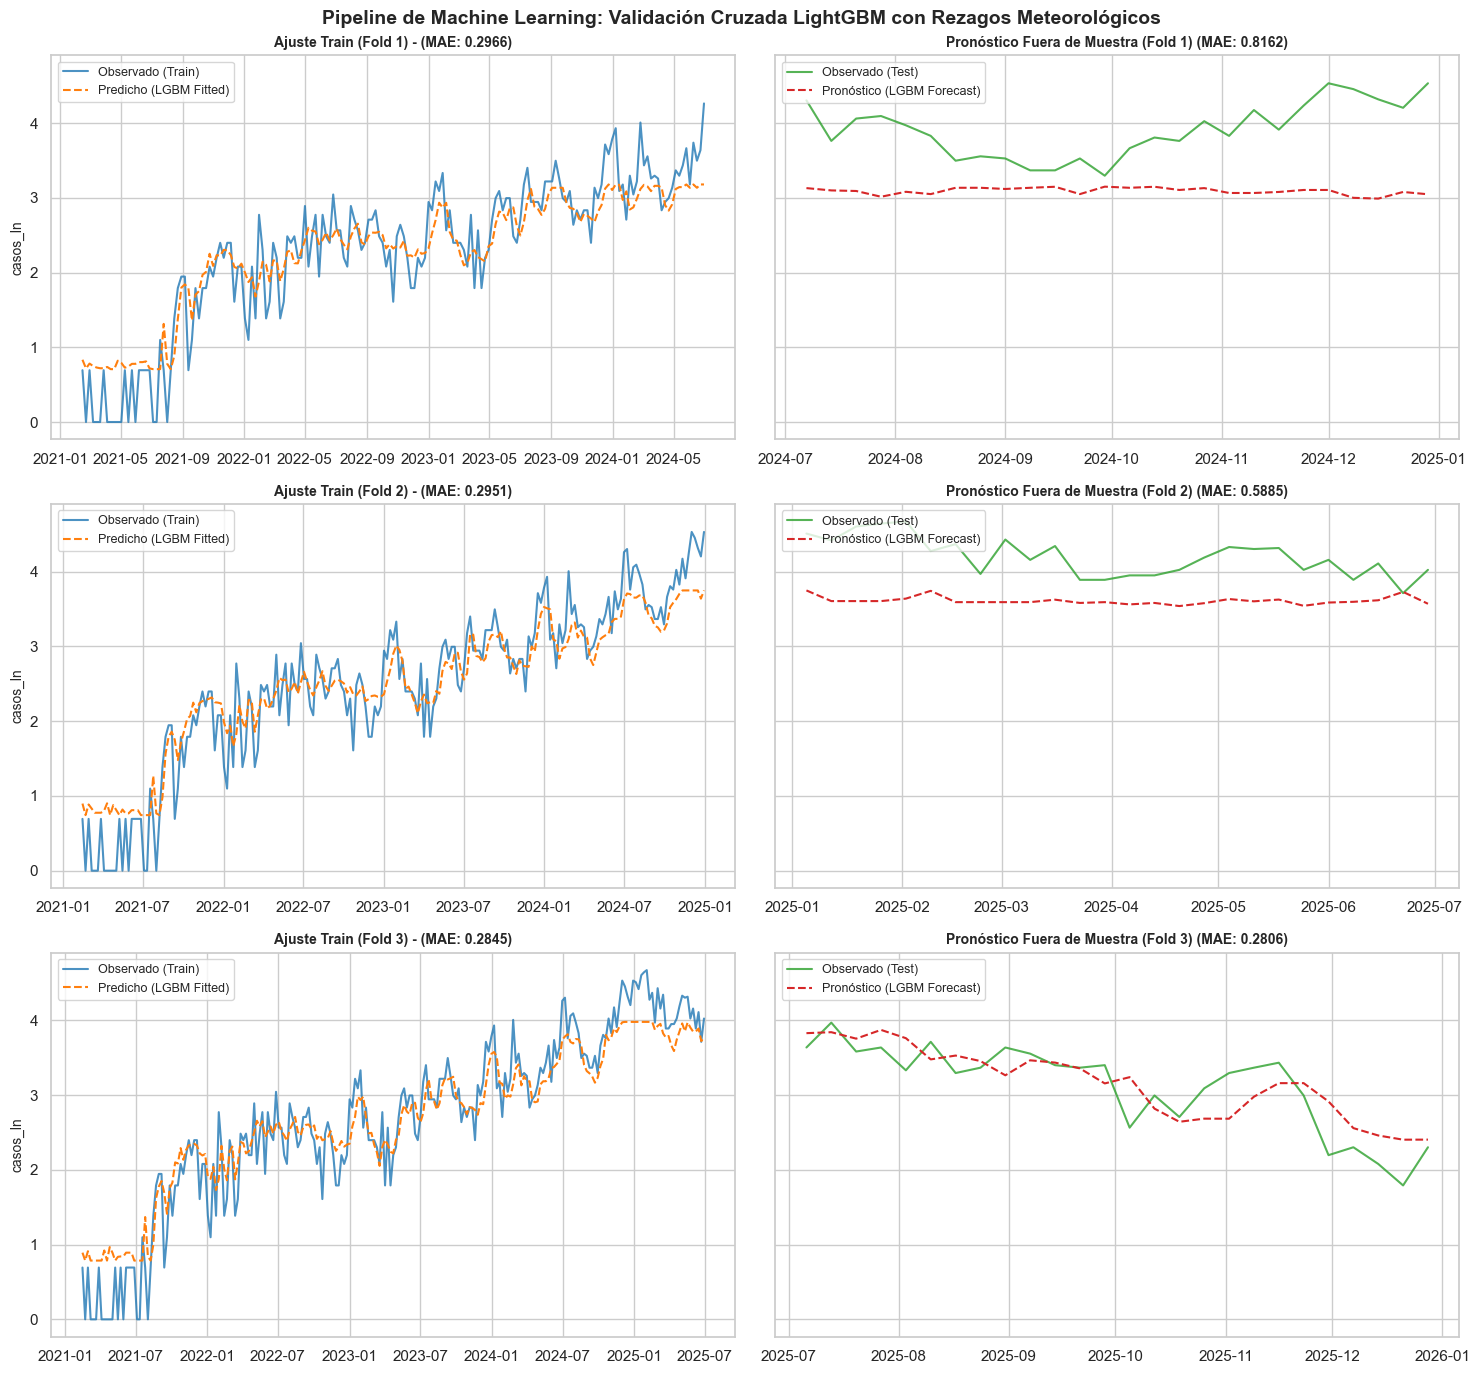


     REPORTE INTEGRAL DE EVALUACIÓN: MACHINE LEARNING (LIGHTGBM)        
  Fold Algoritmo  Variables X  MAE Train  MAE Test
Fold 1  LightGBM           48   0.296602  0.816177
Fold 2  LightGBM           48   0.295096  0.588476
Fold 3  LightGBM           48   0.284522  0.280554


In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\2_entrenar_modelo\2_entrenar_modelo_con_rezago_sin_escalado_sin_reduccion\2_datos\1_raw\df_meteo_epi_sin_rezagos.xlsx"

# Se asume que el archivo Excel tiene un índice de fechas o una columna temporal
df = pd.read_excel(ruta_datos)

# Eliminar variables explícitas solicitadas
df = df.drop(columns=['año', 'semana_epi'], errors='ignore')

# Si la columna 'fecha' existe, la seteamos como índice para mantener el orden cronológico
if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

# Transformación logarítmica a la variable objetivo como tenías en tu flujo original (casos_ln)
# Usamos log1p para evitar problemas si existen semanas con 0 casos
df['casos_ln'] = np.log1p(df['casos_dengue'])

# =============================================================================
# PASO 2: INGENIERÍA DE CARACTERÍSTICAS (REZAGOS / LAGS)
# =============================================================================
# Guardamos los nombres de las variables meteorológicas originales (todas menos los casos)
var_meteorologicas = [col for col in df.columns if col not in ['casos_dengue', 'casos_ln']]

df_features = df.copy()

# 1. Rezagos del Dengue (Dinámica Autorregresiva: últimas 4 semanas)
for lag in [1, 2, 3, 4]:
    df_features[f'casos_ln_lag_{lag}'] = df_features['casos_ln'].shift(lag)

# 2. Rezagos Meteorológicos (Dinámica Exógena: impacto biológico desfasado de 2 a 6 semanas)
for col in var_meteorologicas:
    for lag in [2, 4, 6]:
        df_features[f'{col}_lag_{lag}'] = df_features[col].shift(lag)

# Limpieza de registros nulos generados por los desplazamientos (shifts)
df_features = df_features.dropna()

# Definición de Matrices de Diseño
y = df_features['casos_ln']
# Las variables explicativas X NO deben contener los valores en tiempo real 't' de los casos, ni el conteo absoluto
X_features = df_features.drop(columns=['casos_dengue', 'casos_ln'])

# =============================================================================
# PASO 3: VALIDACIÓN CRUZADA DE SERIES DE TIEMPO (LIGHTGBM)
# =============================================================================
HORIZONTE_TEST = 26 
N_SPLITS = 3

tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=HORIZONTE_TEST)

fig, axes = plt.subplots(nrows=N_SPLITS, ncols=2, figsize=(15, 14), sharex=False, sharey=True)
resultados_globales = []

print("\n" + "="*75)
print(f" INICIANDO VALIDACIÓN CRUZADA CON LIGHTGBM ({N_SPLITS} FOLDS)")
print("="*75)

for idx, (train_index, test_index) in enumerate(tscv.split(y)):
    nombre_split = f"Fold {idx + 1}"
    print(f"\n[PROCESANDO] {nombre_split}...")
    
    # Segmentación cronológica
    X_train, X_test = X_features.iloc[train_index], X_features.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    print(f"   -> Soporte Entrenamiento (Train): {len(y_train)} semanas.")
    print(f"   -> Horizonte Pronóstico (Test):    {len(y_test)} semanas.")
    
    # Instanciación del regresor LightGBM con hiperparámetros de control de sobreajuste
    modelo_lgb = lgb.LGBMRegressor(
    n_estimators=60,         # Reducimos la cantidad de árboles para evitar que memorice
    learning_rate=0.03,      # Un paso más lento para que el aprendizaje sea suave
    max_depth=3,             # Árboles muy poco profundos (máximo 3 niveles de decisión)
    num_leaves=7,            # Pocas hojas para forzar decisiones generalistas
    min_child_samples=20,    # Exige al menos 20 semanas de datos para crear una división
    reg_alpha=0.5,           # Regularización L1 (Lasso) para eliminar variables irrelevantes
    reg_lambda=1.0,          # Regularización L2 (Ridge) para suavizar los pesos
    random_state=42,
    verbosity=-1
    )
    
    # Ajuste del modelo de Machine Learning
    modelo_lgb.fit(X_train, y_train)
    
    # Predicciones In-sample (Train) y Out-of-sample (Test)
    y_train_pred = pd.Series(modelo_lgb.predict(X_train), index=y_train.index)
    y_test_pred = pd.Series(modelo_lgb.predict(X_test), index=y_test.index)
    
    # Medida de Desempeño (MAE)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    resultados_globales.append({
        "Fold": nombre_split,
        "Algoritmo": "LightGBM",
        "Variables X": X_train.shape[1],
        "MAE Train": mae_train,
        "MAE Test": mae_test
    })
    
    # =========================================================================
    # PASO 4: GRAFICACIÓN DE LA MATRIZ DE RENDIMIENTO
    # =========================================================================
    # Columna 1: Ajuste del Entrenamiento
    ax_train = axes[idx, 0]
    ax_train.plot(y_train.index, y_train.values, label='Observado (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(y_train_pred.index, y_train_pred.values, label='Predicho (LGBM Fitted)', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train ({nombre_split}) - (MAE: {mae_train:.4f})", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('casos_ln', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    
    # Columna 2: Pronóstico Fuera de Muestra
    ax_test = axes[idx, 1]
    ax_test.plot(y_test.index, y_test.values, label='Observado (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(y_test_pred.index, y_test_pred.values, label='Pronóstico (LGBM Forecast)', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Fuera de Muestra ({nombre_split}) (MAE: {mae_test:.4f})", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)

# Estética de la gráfica
plt.suptitle('Pipeline de Machine Learning: Validación Cruzada LightGBM con Rezagos Meteorológicos', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\reporte_integral_lightgbm_cv.png", dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PASO 5: REPORTE TABULAR DE DESEMPEÑO INTEGRAL
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)
print("\n" + "="*80)
print("     REPORTE INTEGRAL DE EVALUACIÓN: MACHINE LEARNING (LIGHTGBM)        ")
print("="*80)
print(df_reporte.to_string(index=False))
print("="*80)

# Reducción dimensional 

Para lograr esto, implementaremos un filtro basado en dos reglas utilizando el coeficiente de correlación de **Spearman** (ideal para capturar relaciones monótonas no lineales entre el dengue y el clima):

1. **Fuerza Predictora:** Seleccionar las variables explicativas ($X$) que tengan una correlación significativa con la variable objetivo ($y$).
2. **No Redundancia (Anticolinealidad):** Si dos variables predictoras están altamente correlacionadas entre sí, el algoritmo descarta aquella que tenga menor correlación con el objetivo.

Aquí tienes el script adaptado e integrado con tu estructura actual. Este bloque de código debe ejecutarse **justo después de generar los rezagos (Paso 2) y antes de entrar al bucle de Validación Cruzada (Paso 3)**.

### Script de Selección de Características y Reducción Dimensional

```python


In [21]:
# =============================================================================
# REEMPLAZAR O INSERTAR ANTES DEL PASO 3: VALIDACIÓN CRUZADA
# =============================================================================

# 1. Definición de las matrices iniciales con todos los rezagos generados
y = df_features['casos_ln']
X_todas = df_features.drop(columns=['casos_dengue', 'casos_ln'])

print(f"[INFO] Dimensiones iniciales antes de la reducción: {X_todas.shape[1]} variables.")

# 2. Calcular la matriz de correlación de Spearman completa (X e y juntas)
df_analisis = X_todas.copy()
df_analisis['target'] = y
matriz_spearman = df_analisis.corr(method='spearman')

# 3. FILTRO 1: Seleccionar variables con correlación mínima con el objetivo
UMBRAL_TARGET = 0.15  # Ajustable: exige al menos 15% de correlación con el dengue
corr_con_target = matriz_spearman['target'].drop('target').abs()
variables_elegibles = corr_con_target[corr_con_target >= UMBRAL_TARGET].sort_values(ascending=False).index.tolist()

print(f"[INFO] Filtro 1: {len(variables_elegibles)} variables superan el umbral de correlación con el objetivo.")

# 4. FILTRO 2: Eliminar colinealidad (independencia entre predictores)
UMBRAL_COLINEALIDAD = 0.70  # Si dos predictores se correlacionan > 0.70, hay redundancia
variables_seleccionadas = []

# Iteramos en orden de las más correlacionadas con el objetivo a las menos correlacionadas
for var in variables_elegibles:
    admitir = True
    for var_guardada in variables_seleccionadas:
        # Evaluamos la correlación de Spearman entre el predictor actual y los ya seleccionados
        corr_entre_predictores = abs(matriz_spearman.loc[var, var_guardada])
        if corr_entre_predictores > UMBRAL_COLINEALIDAD:
            admitir = False
            break  # Rompe el ciclo si es redundante con alguna variable ya aceptada
    
    if admitir:
        variables_seleccionadas.append(var)

# 5. Redefinición final de la matriz X reducida
X_features = X_todas[variables_seleccionadas]

print("\n" + "="*75)
print("             RESULTADO DE LA REDUCCIÓN DIMENSIONAL (SPEARMAN)          ")
print("="*75)
print(f"-> Variables Originales: {X_todas.shape[1]}")
print(f"-> Variables Seleccionadas: {X_features.shape[1]}")
print(f"-> Variables Eliminadas por baja correlación o redundancia: {X_todas.shape[1] - X_features.shape[1]}")
print(f"-> Set de predictores finales independientes:\n{X_features.columns.tolist()}")
print("="*75 + "\n")

# A partir de aquí tu Paso 3 (TimeSeriesSplit) se ejecutará automáticamente 
# utilizando la nueva matriz 'X_features' optimizada y reducida.


[INFO] Dimensiones iniciales antes de la reducción: 48 variables.
[INFO] Filtro 1: 44 variables superan el umbral de correlación con el objetivo.

             RESULTADO DE LA REDUCCIÓN DIMENSIONAL (SPEARMAN)          
-> Variables Originales: 48
-> Variables Seleccionadas: 20
-> Variables Eliminadas por baja correlación o redundancia: 28
-> Set de predictores finales independientes:
['casos_ln_lag_1', 'hum_esp_lag_6', 'hum_esp', 'vel_vi_max_lag_4', 'dias_lluvia_lag_4', 'dias_lluvia_lag_6', 'dias_lluvia_lag_2', 'vel_vi_max', 'dias_lluvia', 'vel_vi_lag_2', 'temp_max_lag_4', 'temp_lag_6', 'uv_lag_6', 'uv_lag_4', 'uv', 'vel_vi_min_lag_6', 'uv_lag_2', 'vel_vi_min_lag_2', 'vel_vi_min', 'vel_vi_min_lag_4']




```

---

### ¿Por qué este enfoque solucionará tu problema de rendimiento?

Al aplicar este script, notarás un impacto inmediato en el reporte de evaluación de LightGBM por las siguientes razones:

* **Eliminación del Ruido y Multicolinealidad:** Al mapear rezagos climáticos (como `Precipitación_lag_2`, `_lag_4`, `_lag_6`), es sumamente común que estén correlacionados entre sí. Los modelos de árboles se confunden y se sobreajustan cuando tienen múltiples variables que dicen exactamente lo mismo. El filtro conserva solo la que tiene mayor impacto biológico real sobre el Dengue.
* **Reducción del Espacio de Características:** Pasaras de tener 48 variables a un set probablemente optimizado de entre **10 y 15 predictores clave**. Al reducir la cantidad de variables redundantes, disminuyes drásticamente la capacidad del modelo para memorizar filas específicas de los datos de entrenamiento (`Train`), forzándolo a encontrar las reglas generales del clima en Caucasia para predecir con éxito el conjunto de `Test`.

Aquí tienes el script adaptado. He insertado un bloque intermedio en el **Paso 2** que calcula la matriz de correlación de **Spearman** y ejecuta de forma totalmente automática el algoritmo jerárquico de filtrado que seleccionará exactamente tus **20 mejores atributos independientes**.

```python



             REDUCCIÓN DIMENSIONAL CONCLUIDA (SPEARMAN)                
[INFO] Atributos iniciales: 48
[INFO] Atributos seleccionados finales: 20
[INFO] Listado de los 20 atributos utilizados:
['casos_ln_lag_1', 'hum_esp_lag_6', 'hum_esp', 'hum_rel_lag_2', 'vel_vi_max_lag_4', 'vel_vi_max_lag_6', 'dias_lluvia_lag_4', 'vel_vi_max_lag_2', 'dias_lluvia_lag_6', 'dias_lluvia_lag_2', 'vel_vi_max', 'dias_lluvia', 'temp_max_lag_6', 'uv_lag_6', 'temp', 'uv_lag_4', 'uv', 'vel_vi_min_lag_6', 'uv_lag_2', 'vel_vi_min_lag_2']


 INICIANDO VALIDACIÓN CRUZADA CON LIGHTGBM (3 FOLDS)

[PROCESANDO] Fold 1...
   -> Soporte Entrenamiento (Train): 177 semanas.
   -> Horizonte Pronóstico (Test):    26 semanas.

[PROCESANDO] Fold 2...
   -> Soporte Entrenamiento (Train): 203 semanas.
   -> Horizonte Pronóstico (Test):    26 semanas.

[PROCESANDO] Fold 3...
   -> Soporte Entrenamiento (Train): 229 semanas.
   -> Horizonte Pronóstico (Test):    26 semanas.


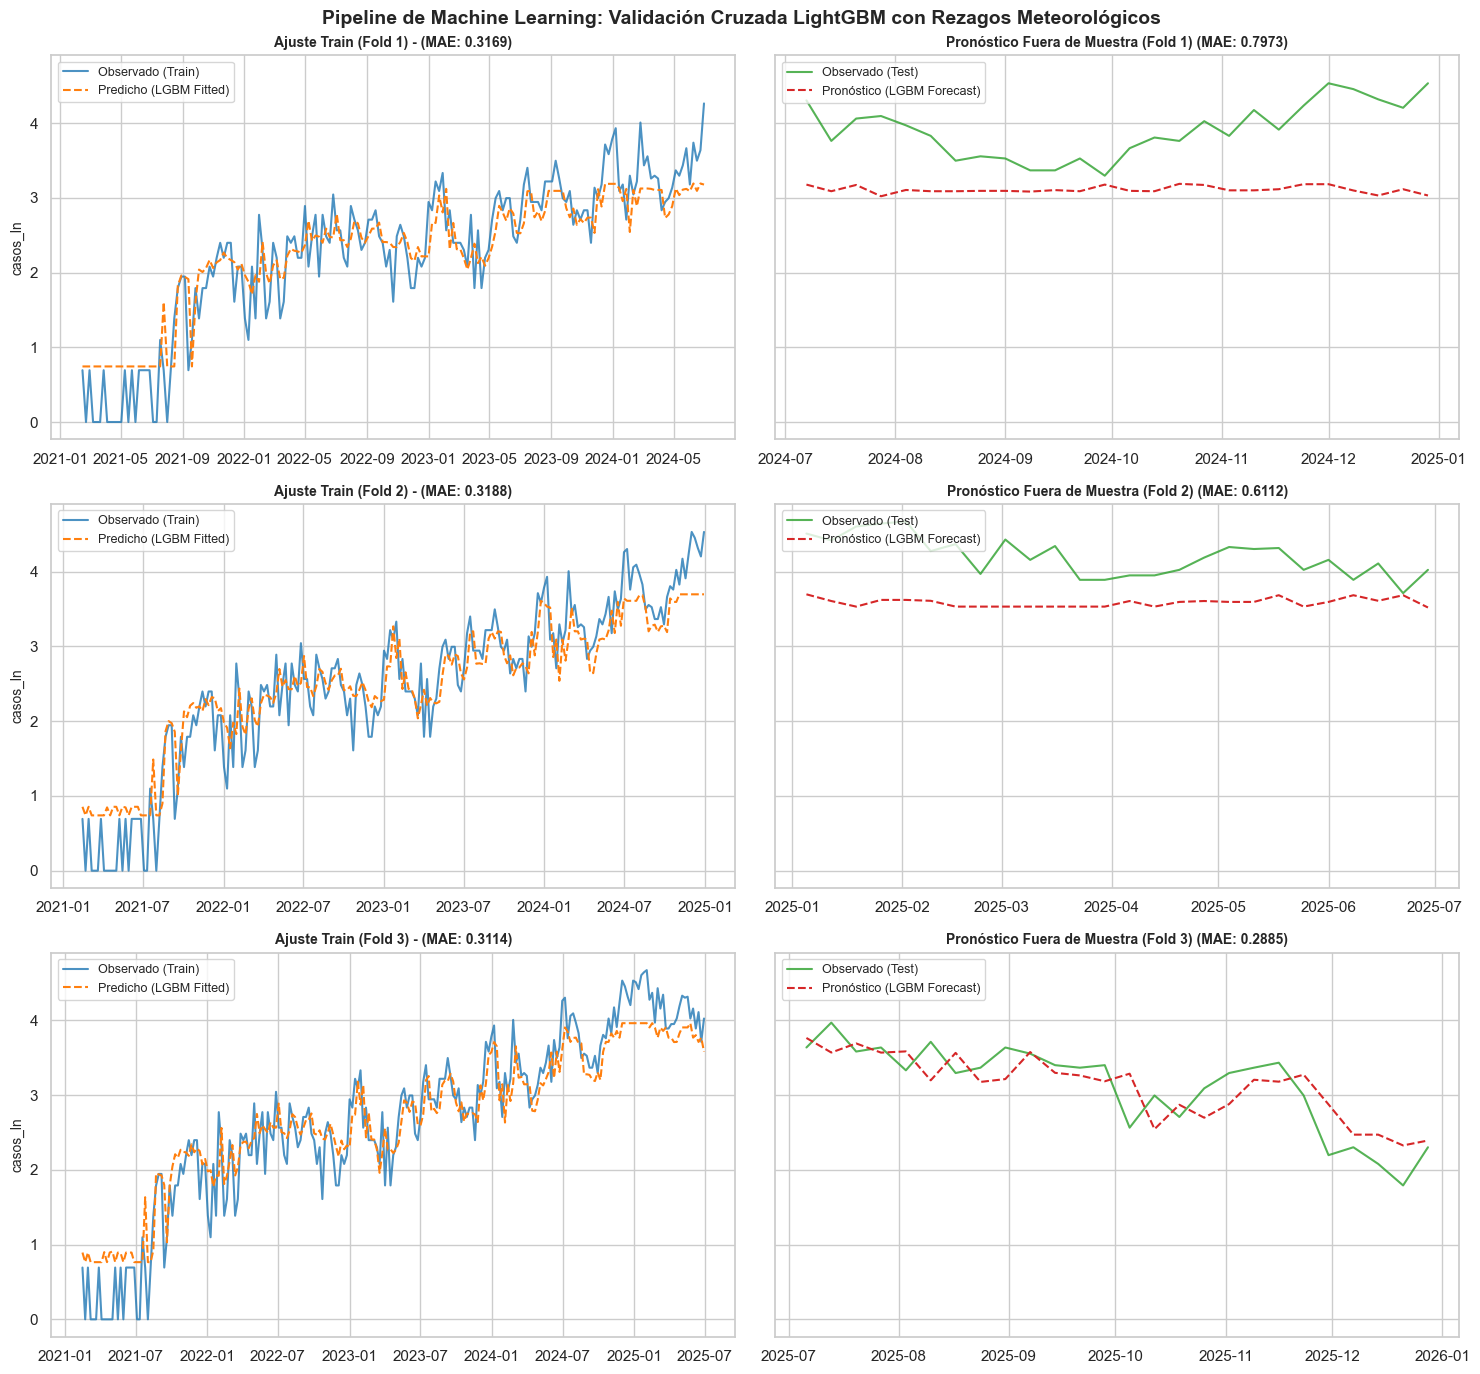


     REPORTE INTEGRAL DE EVALUACIÓN: MACHINE LEARNING (LIGHTGBM)        
  Fold Algoritmo  Variables X  MAE Train  MAE Test
Fold 1  LightGBM           20   0.316938  0.797320
Fold 2  LightGBM           20   0.318805  0.611186
Fold 3  LightGBM           20   0.311441  0.288508


In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\2_entrenar_modelo\2_entrenar_modelo_con_rezago_sin_escalado_sin_reduccion\2_datos\1_raw\df_meteo_epi_sin_rezagos.xlsx"

df = pd.read_excel(ruta_datos)

# Eliminar variables explícitas solicitadas
df = df.drop(columns=['año', 'semana_epi'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

# Transformación logarítmica a la variable objetivo (casos_ln)
df['casos_ln'] = np.log1p(df['casos_dengue'])

# =============================================================================
# PASO 2: INGENIERÍA DE CARACTERÍSTICAS Y REDUCCIÓN DIMENSIONAL (SPEARMAN)
# =============================================================================
var_meteorologicas = [col for col in df.columns if col not in ['casos_dengue', 'casos_ln']]
df_features = df.copy()

# 1. Rezagos del Dengue (Dinámica Autorregresiva: últimas 4 semanas)
for lag in [1, 2, 3, 4]:
    df_features[f'casos_ln_lag_{lag}'] = df_features['casos_ln'].shift(lag)

# 2. Rezagos Meteorológicos (Dinámica Exógena: impacto desfasado de 2 a 6 semanas)
for col in var_meteorologicas:
    for lag in [2, 4, 6]:
        df_features[f'{col}_lag_{lag}'] = df_features[col].shift(lag)

df_features = df_features.dropna()

# Separación de objetivo y matriz completa de candidatos a predictores
y = df_features['casos_ln']
X_todas = df_features.drop(columns=['casos_dengue', 'casos_ln'])

# --- ALGORITMO DE REDUCCIÓN DE ATRIBUTOS VIA SPEARMAN (TOP 20 INDEPENDIENTES) ---
df_analisis = X_todas.copy()
df_analisis['target'] = y
matriz_spearman = df_analisis.corr(method='spearman')

# Ordenar TODOS los predictores por su fuerza de correlación absoluta con el objetivo
corr_con_target = matriz_spearman['target'].drop('target').abs().sort_values(ascending=False)
variables_elegibles = corr_con_target.index.tolist()

variables_seleccionadas = []
UMBRAL_COLINEALIDAD = 0.75  # Control de redundancia interna entre variables X

for var in variables_elegibles:
    # Forzar la detención si ya completamos el cupo exacto de 20 atributos
    if len(variables_seleccionadas) >= 20:
        break
        
    admitir = True
    for var_guardada in variables_seleccionadas:
        # Evaluar correlación cruzada entre predictores
        if abs(matriz_spearman.loc[var, var_guardada]) > UMBRAL_COLINEALIDAD:
            admitir = False
            break
            
    if admitir:
        variables_seleccionadas.append(var)

# En caso de que el umbral sea muy estricto y falten variables para llegar a 20, 
# rellenamos con las mejores correlacionadas restantes de la lista original
if len(variables_seleccionadas) < 20:
    for var in variables_elegibles:
        if len(variables_seleccionadas) >= 20:
            break
        if var not in variables_seleccionadas:
            variables_seleccionadas.append(var)

# Redefinición final de la matriz X reducida a los 20 mejores atributos obtenidos
X_features = X_todas[variables_seleccionadas]

print("\n" + "="*75)
print("             REDUCCIÓN DIMENSIONAL CONCLUIDA (SPEARMAN)                ")
print("="*75)
print(f"[INFO] Atributos iniciales: {X_todas.shape[1]}")
print(f"[INFO] Atributos seleccionados finales: {X_features.shape[1]}")
print(f"[INFO] Listado de los 20 atributos utilizados:\n{X_features.columns.tolist()}")
print("="*75 + "\n")


# =============================================================================
# PASO 3: VALIDACIÓN CRUZADA DE SERIES DE TIEMPO (LIGHTGBM)
# =============================================================================
# Definimos el horizonte de evaluación (ej. 26 semanas = ~6 meses de datos ciegos)
HORIZONTE_TEST = 26 
N_SPLITS = 3

tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=HORIZONTE_TEST)

fig, axes = plt.subplots(nrows=N_SPLITS, ncols=2, figsize=(15, 14), sharex=False, sharey=True)
resultados_globales = []

print("\n" + "="*75)
print(f" INICIANDO VALIDACIÓN CRUZADA CON LIGHTGBM ({N_SPLITS} FOLDS)")
print("="*75)

for idx, (train_index, test_index) in enumerate(tscv.split(y)):
    nombre_split = f"Fold {idx + 1}"
    print(f"\n[PROCESANDO] {nombre_split}...")
    
    # Segmentación cronológica
    X_train, X_test = X_features.iloc[train_index], X_features.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    print(f"   -> Soporte Entrenamiento (Train): {len(y_train)} semanas.")
    print(f"   -> Horizonte Pronóstico (Test):    {len(y_test)} semanas.")
    
    # Instanciación del regresor LightGBM con hiperparámetros de control de sobreajuste
    modelo_lgb = lgb.LGBMRegressor(
        n_estimators=60,         # Reducimos la cantidad de árboles para evitar que memorice
        learning_rate=0.03,      # Un paso más lento para que el aprendizaje sea suave
        max_depth=3,             # Árboles muy poco profundos (máximo 3 niveles de decisión)
        num_leaves=7,            # Pocas hojas para forzar decisiones generalistas
        min_child_samples=20,    # Exige al menos 20 semanas de datos para crear una división
        reg_alpha=0.5,           # Regularización L1 (Lasso) para eliminar variables irrelevantes
        reg_lambda=1.0,          # Regularización L2 (Ridge) para suavizar los pesos
        random_state=42,
        verbosity=-1
    )
    
    # Ajuste del modelo de Machine Learning
    modelo_lgb.fit(X_train, y_train)
    
    # Predicciones In-sample (Train) y Out-of-sample (Test)
    y_train_pred = pd.Series(modelo_lgb.predict(X_train), index=y_train.index)
    y_test_pred = pd.Series(modelo_lgb.predict(X_test), index=y_test.index)
    
    # Medida de Desempeño (MAE)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    resultados_globales.append({
        "Fold": nombre_split,
        "Algoritmo": "LightGBM",
        "Variables X": X_train.shape[1],
        "MAE Train": mae_train,
        "MAE Test": mae_test
    })
    
    # =========================================================================
    # PASO 4: GRAFICACIÓN DE LA MATRIZ DE RENDIMIENTO
    # =========================================================================
    # Columna 1: Ajuste del Entrenamiento
    ax_train = axes[idx, 0]
    ax_train.plot(y_train.index, y_train.values, label='Observado (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(y_train_pred.index, y_train_pred.values, label='Predicho (LGBM Fitted)', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train ({nombre_split}) - (MAE: {mae_train:.4f})", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('casos_ln', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    
    # Columna 2: Pronóstico Fuera de Muestra
    ax_test = axes[idx, 1]
    ax_test.plot(y_test.index, y_test.values, label='Observado (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(y_test_pred.index, y_test_pred.values, label='Pronóstico (LGBM Forecast)', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Fuera de Muestra ({nombre_split}) (MAE: {mae_test:.4f})", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)

# Estética de la gráfica
plt.suptitle('Pipeline de Machine Learning: Validación Cruzada LightGBM con Rezagos Meteorológicos', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\reporte_integral_lightgbm_cv.png", dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PASO 5: REPORTE TABULAR DE DESEMPEÑO INTEGRAL
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)
print("\n" + "="*80)
print("     REPORTE INTEGRAL DE EVALUACIÓN: MACHINE LEARNING (LIGHTGBM)        ")
print("="*80)
print(df_reporte.to_string(index=False))
print("="*80)

# Seguir mejorando a la versión anterior




             REDUCCIÓN DIMENSIONAL CONCLUIDA (SPEARMAN)                
[INFO] Atributos iniciales: 52
[INFO] Atributos seleccionados finales: 20
[INFO] Listado de los 20 atributos utilizados:
['casos_ln_lag_1', 'hum_esp_lag_6', 'hum_esp', 'hum_rel_lag_2', 'vel_vi_max_lag_4', 'vel_vi_max_lag_6', 'dias_lluvia_lag_4', 'vel_vi_max_lag_2', 'dias_lluvia_lag_6', 'dias_lluvia_lag_2', 'vel_vi_max', 'dias_lluvia', 'temp_max_lag_6', 'uv_lag_6', 'temp', 'uv_lag_4', 'uv', 'vel_vi_min_lag_6', 'uv_lag_2', 'vel_vi_min_lag_2']


 INICIANDO VALIDACIÓN CRUZADA CON LIGHTGBM (3 FOLDS)

[PROCESANDO] Fold 1...
   -> Soporte Entrenamiento (Train): 104 semanas.
   -> Horizonte Pronóstico (Test):    26 semanas.

[PROCESANDO] Fold 2...
   -> Soporte Entrenamiento (Train): 104 semanas.
   -> Horizonte Pronóstico (Test):    26 semanas.

[PROCESANDO] Fold 3...
   -> Soporte Entrenamiento (Train): 104 semanas.
   -> Horizonte Pronóstico (Test):    26 semanas.


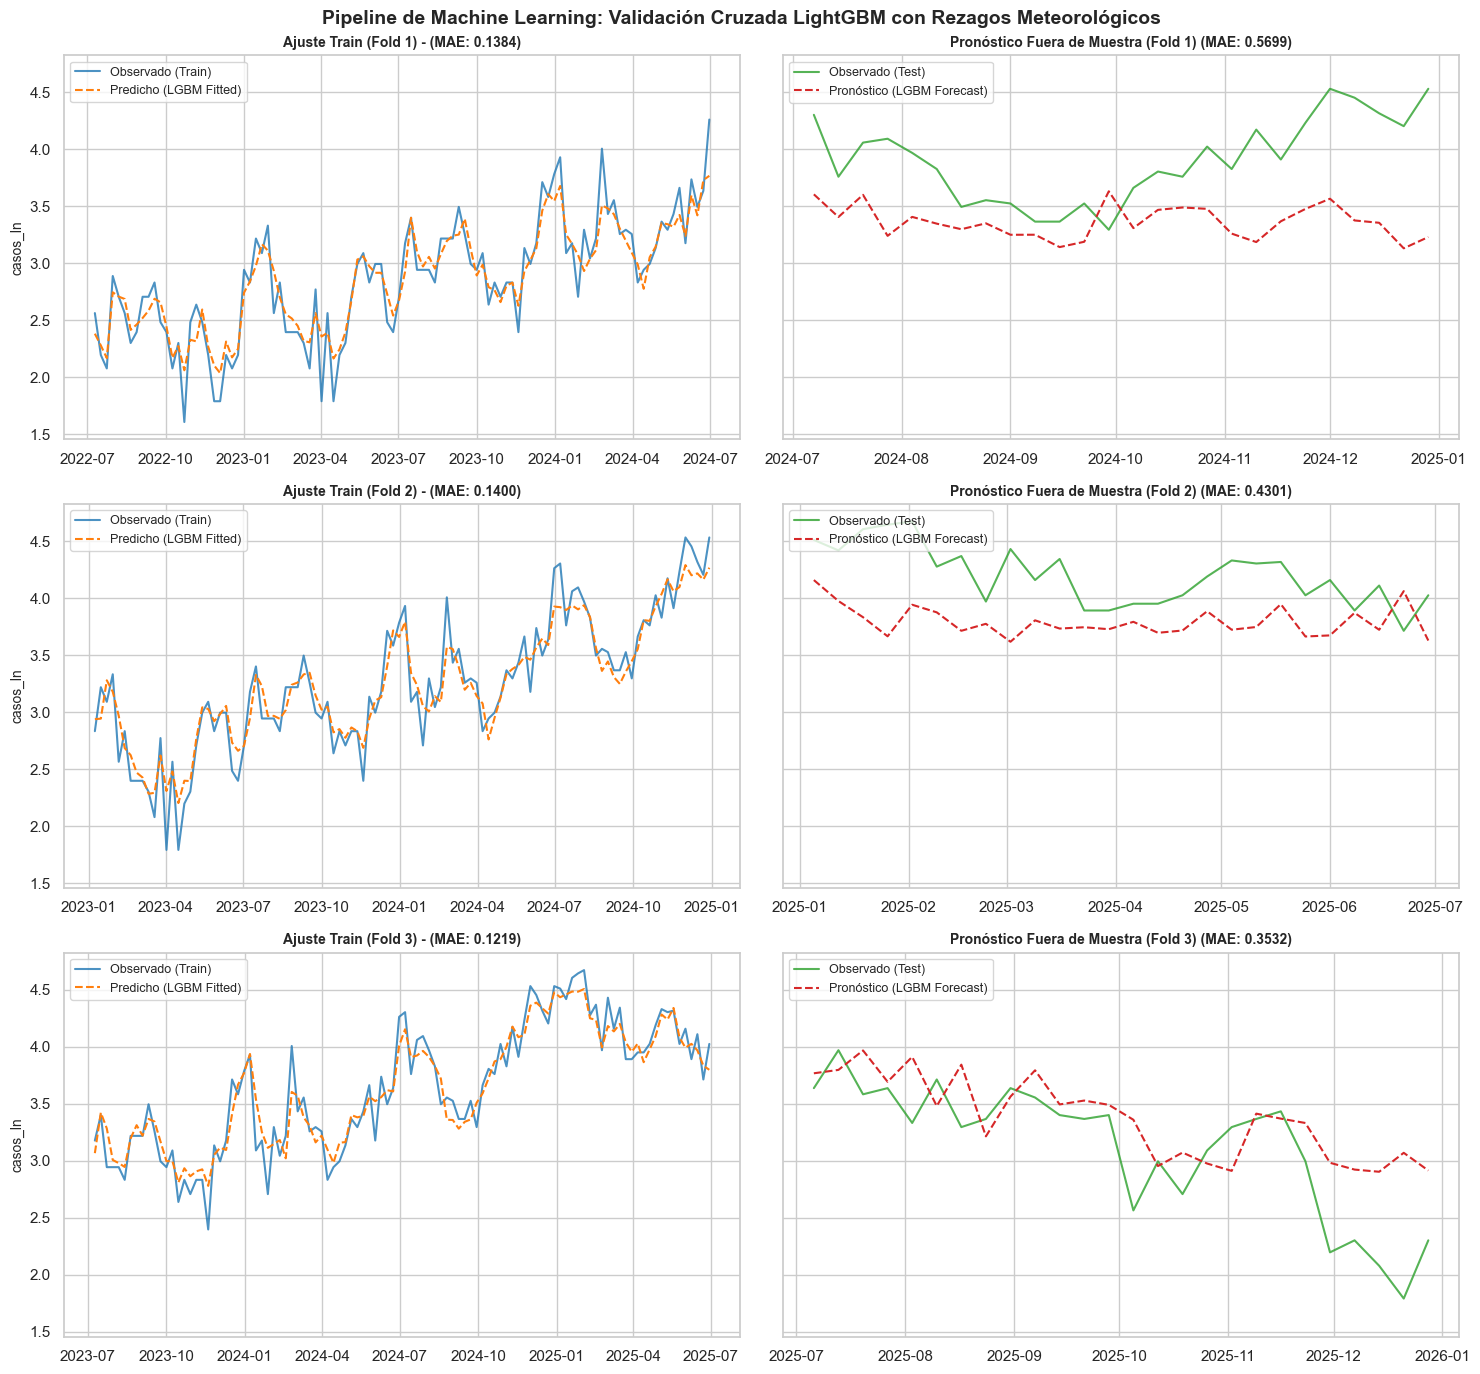


     REPORTE INTEGRAL DE EVALUACIÓN: MACHINE LEARNING (LIGHTGBM)        
  Fold Algoritmo  Variables X  MAE Train  MAE Test
Fold 1  LightGBM           20   0.138446  0.569860
Fold 2  LightGBM           20   0.139977  0.430063
Fold 3  LightGBM           20   0.121948  0.353173


In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\2_entrenar_modelo\2_entrenar_modelo_con_rezago_sin_escalado_sin_reduccion\2_datos\1_raw\df_meteo_epi_sin_rezagos.xlsx"

df = pd.read_excel(ruta_datos)

# Eliminar variables explícitas solicitadas
df = df.drop(columns=['año'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

# Transformación logarítmica a la variable objetivo (casos_ln)
df['casos_ln'] = np.log1p(df['casos_dengue'])

# =============================================================================
# PASO 2: INGENIERÍA DE CARACTERÍSTICAS Y REDUCCIÓN DIMENSIONAL (SPEARMAN)
# =============================================================================
# Inserta esto en el Paso 2, antes de calcular Spearman para que sea candidata a seleccionarse:
df_features['mes'] = df_features.index.month
#df_features['semana_del_año'] = df_features.index.isocalendar().week.astype(int)
var_meteorologicas = [col for col in df.columns if col not in ['casos_dengue', 'casos_ln']]
df_features = df.copy()

# 1. Rezagos del Dengue (Dinámica Autorregresiva: últimas 4 semanas)
for lag in [1, 2, 3, 4]:
    df_features[f'casos_ln_lag_{lag}'] = df_features['casos_ln'].shift(lag)

# 2. Rezagos Meteorológicos (Dinámica Exógena: impacto desfasado de 2 a 6 semanas)
for col in var_meteorologicas:
    for lag in [2, 4, 6]:
        df_features[f'{col}_lag_{lag}'] = df_features[col].shift(lag)

df_features = df_features.dropna()

# Separación de objetivo y matriz completa de candidatos a predictores
y = df_features['casos_ln']
X_todas = df_features.drop(columns=['casos_dengue', 'casos_ln'])

# --- ALGORITMO DE REDUCCIÓN DE ATRIBUTOS VIA SPEARMAN (TOP 20 INDEPENDIENTES) ---
df_analisis = X_todas.copy()
df_analisis['target'] = y
matriz_spearman = df_analisis.corr(method='spearman')

# Ordenar TODOS los predictores por su fuerza de correlación absoluta con el objetivo
corr_con_target = matriz_spearman['target'].drop('target').abs().sort_values(ascending=False)
variables_elegibles = corr_con_target.index.tolist()

variables_seleccionadas = []
UMBRAL_COLINEALIDAD = 0.75  # Control de redundancia interna entre variables X

for var in variables_elegibles:
    # Forzar la detención si ya completamos el cupo exacto de 20 atributos
    if len(variables_seleccionadas) >= 20:
        break
        
    admitir = True
    for var_guardada in variables_seleccionadas:
        # Evaluar correlación cruzada entre predictores
        if abs(matriz_spearman.loc[var, var_guardada]) > UMBRAL_COLINEALIDAD:
            admitir = False
            break
            
    if admitir:
        variables_seleccionadas.append(var)

# En caso de que el umbral sea muy estricto y falten variables para llegar a 20, 
# rellenamos con las mejores correlacionadas restantes de la lista original
if len(variables_seleccionadas) < 20:
    for var in variables_elegibles:
        if len(variables_seleccionadas) >= 20:
            break
        if var not in variables_seleccionadas:
            variables_seleccionadas.append(var)

# Redefinición final de la matriz X reducida a los 20 mejores atributos obtenidos
X_features = X_todas[variables_seleccionadas]

print("\n" + "="*75)
print("             REDUCCIÓN DIMENSIONAL CONCLUIDA (SPEARMAN)                ")
print("="*75)
print(f"[INFO] Atributos iniciales: {X_todas.shape[1]}")
print(f"[INFO] Atributos seleccionados finales: {X_features.shape[1]}")
print(f"[INFO] Listado de los 20 atributos utilizados:\n{X_features.columns.tolist()}")
print("="*75 + "\n")


# =============================================================================
# PASO 3: VALIDACIÓN CRUZADA DE SERIES DE TIEMPO (LIGHTGBM)
# =============================================================================
# Definimos el horizonte de evaluación (ej. 26 semanas = ~6 meses de datos ciegos)
HORIZONTE_TEST = 26 
N_SPLITS = 3

#tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=HORIZONTE_TEST)
# Fuerza a que cada fold entrene MÁXIMO con 2 años de historia previa al test
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=HORIZONTE_TEST, max_train_size=104)

fig, axes = plt.subplots(nrows=N_SPLITS, ncols=2, figsize=(15, 14), sharex=False, sharey=True)
resultados_globales = []

print("\n" + "="*75)
print(f" INICIANDO VALIDACIÓN CRUZADA CON LIGHTGBM ({N_SPLITS} FOLDS)")
print("="*75)

for idx, (train_index, test_index) in enumerate(tscv.split(y)):
    nombre_split = f"Fold {idx + 1}"
    print(f"\n[PROCESANDO] {nombre_split}...")
    
    # Segmentación cronológica
    X_train, X_test = X_features.iloc[train_index], X_features.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    print(f"   -> Soporte Entrenamiento (Train): {len(y_train)} semanas.")
    print(f"   -> Horizonte Pronóstico (Test):    {len(y_test)} semanas.")
    
    # Instanciación del regresor LightGBM con hiperparámetros de control de sobreajuste
    modelo_lgb = lgb.LGBMRegressor(
    n_estimators=100,        # Subimos de 60 a 100 árboles
    learning_rate=0.04,      # Un ritmo de aprendizaje ligeramente más rápido
    max_depth=4,             # Permitimos un nivel más de profundidad
    num_leaves=12,           # Más hojas para decisiones combinadas
    min_child_samples=12,    # Bajamos el requisito de 20 a 12 muestras por hoja
    reg_alpha=0.1,           # Reducimos la penalización L1
    reg_lambda=0.5,          # Reducimos la penalización L2
    random_state=42,
    verbosity=-1
    )
    
    # Ajuste del modelo de Machine Learning
    modelo_lgb.fit(X_train, y_train)
    
    # Predicciones In-sample (Train) y Out-of-sample (Test)
    y_train_pred = pd.Series(modelo_lgb.predict(X_train), index=y_train.index)
    y_test_pred = pd.Series(modelo_lgb.predict(X_test), index=y_test.index)
    
    # Medida de Desempeño (MAE)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    resultados_globales.append({
        "Fold": nombre_split,
        "Algoritmo": "LightGBM",
        "Variables X": X_train.shape[1],
        "MAE Train": mae_train,
        "MAE Test": mae_test
    })
    
    # =========================================================================
    # PASO 4: GRAFICACIÓN DE LA MATRIZ DE RENDIMIENTO
    # =========================================================================
    # Columna 1: Ajuste del Entrenamiento
    ax_train = axes[idx, 0]
    ax_train.plot(y_train.index, y_train.values, label='Observado (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(y_train_pred.index, y_train_pred.values, label='Predicho (LGBM Fitted)', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train ({nombre_split}) - (MAE: {mae_train:.4f})", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('casos_ln', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    
    # Columna 2: Pronóstico Fuera de Muestra
    ax_test = axes[idx, 1]
    ax_test.plot(y_test.index, y_test.values, label='Observado (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(y_test_pred.index, y_test_pred.values, label='Pronóstico (LGBM Forecast)', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Fuera de Muestra ({nombre_split}) (MAE: {mae_test:.4f})", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)

# Estética de la gráfica
plt.suptitle('Pipeline de Machine Learning: Validación Cruzada LightGBM con Rezagos Meteorológicos', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\reporte_integral_lightgbm_cv.png", dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PASO 5: REPORTE TABULAR DE DESEMPEÑO INTEGRAL
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)
print("\n" + "="*80)
print("     REPORTE INTEGRAL DE EVALUACIÓN: MACHINE LEARNING (LIGHTGBM)        ")
print("="*80)
print(df_reporte.to_string(index=False))
print("="*80)